--- WEEK 1 METRICS ---
Nodes: 126
Edges: 281
Average Degree: 4.46
Density: 0.0357



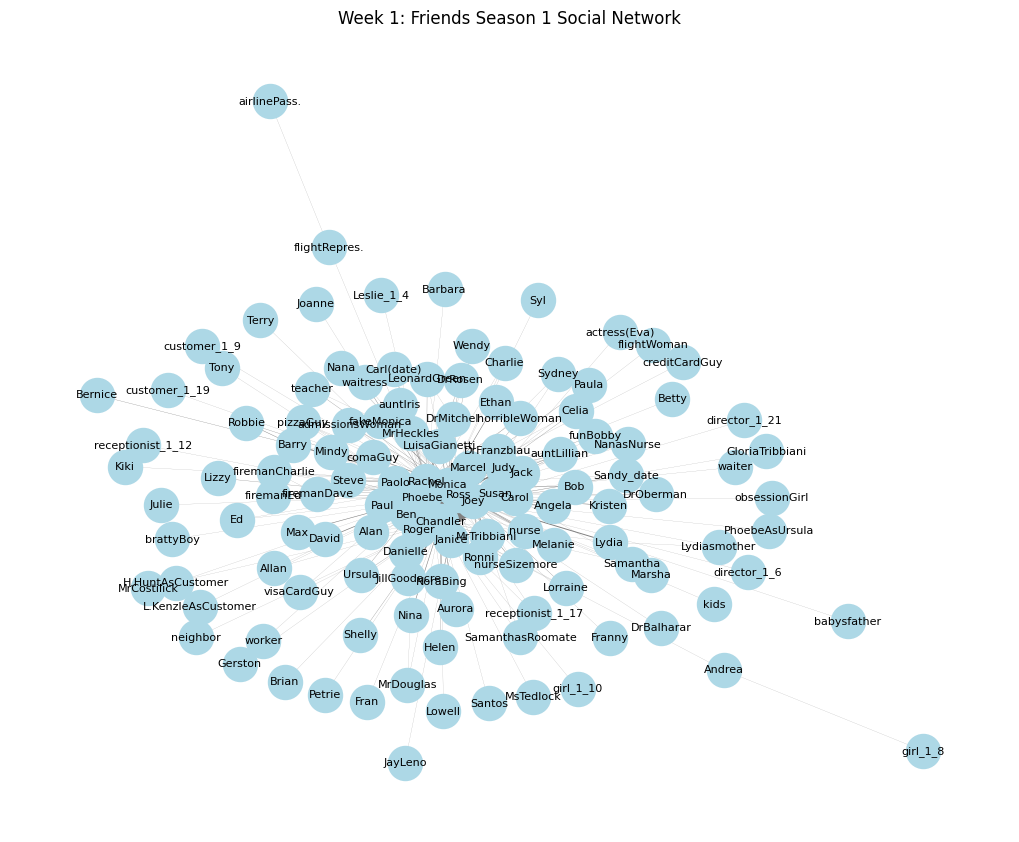

--- WEEK 2 METRICS (Largest Component) ---
Custom Avg Clustering: 0.5058
NetworkX Avg Clustering: 0.5058
NetworkX Transitivity: 0.1593



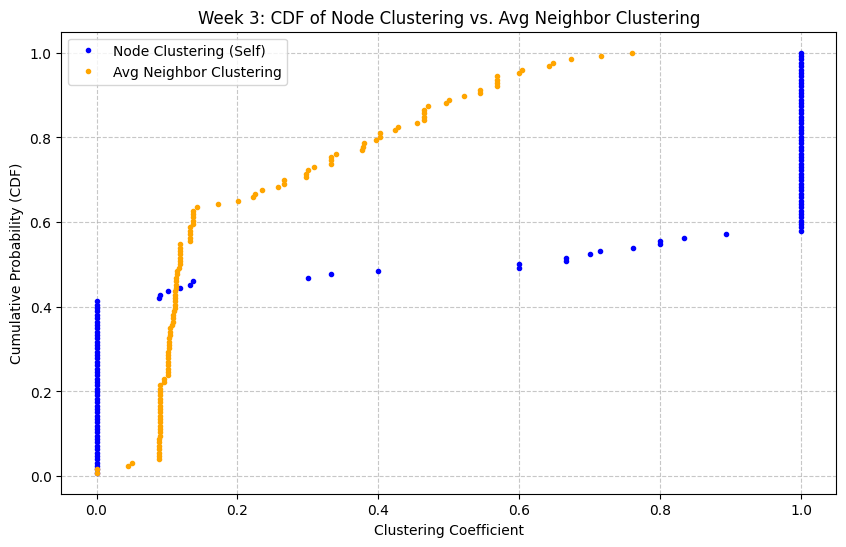

In [ ]:
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np

# ==========================================
# PREPROCESSING & WEEK 1
# ==========================================

G = nx.Graph()

with open('friends_episodes.txt', 'r') as file:
    for line in file:
        # Fixed: Now it looks for '#s2e1' exactly as it is in the file!
        if '#s2e1' in line:
            break

        # Clean up the line by splitting at the ']'
        if ']' in line:
            line = line.split(']')[-1]

        line = line.strip()

        # Skip empty lines and comments
        if not line or line.startswith('#'):
            continue

        # Extract the two characters (nodes)
        nodes = line.split()
        if len(nodes) >= 2:
            u, v = nodes[0], nodes[1]
            if G.has_edge(u, v):
                G[u][v]['weight'] += 1
            else:
                G.add_edge(u, v, weight=1)

print("--- WEEK 1 METRICS ---")
num_nodes = G.number_of_nodes()
num_edges = G.number_of_edges()
avg_degree = (2 * num_edges) / num_nodes
density = nx.density(G)

print(f"Nodes: {num_nodes}")
print(f"Edges: {num_edges}")
print(f"Average Degree: {avg_degree:.2f}")
print(f"Density: {density:.4f}\n")

# Draw the graph
plt.figure(figsize=(10, 8))
pos = nx.spring_layout(G, seed=42)
weights = [G[u][v]['weight'] * 0.1 for u, v in G.edges()]
nx.draw(G, pos, with_labels=True, node_color='lightblue',
        node_size=600, font_size=8, width=weights, edge_color='gray')
plt.title("Week 1: Friends Season 1 Social Network")
plt.show()

# ==========================================
# WEEK 2: CLUSTERING & TRANSITIVITY
# ==========================================

# 1. Extract largest connected component
largest_cc_nodes = max(nx.connected_components(G), key=len)
G_lc = G.subgraph(largest_cc_nodes).copy()

# 2. Custom node clustering function
def get_node_clustering(graph, node):
    neighbors = list(graph.neighbors(node))
    k = len(neighbors)
    if k < 2:
        return 0.0
    edges_between_neighbors = sum(1 for i in range(k) for j in range(i + 1, k)
                                  if graph.has_edge(neighbors[i], neighbors[j]))
    return (2.0 * edges_between_neighbors) / (k * (k - 1))

# 3. Custom average clustering function
def get_average_clustering(graph):
    clusterings = [get_node_clustering(graph, n) for n in graph.nodes()]
    return sum(clusterings) / len(clusterings)

my_avg_clustering = get_average_clustering(G_lc)
nx_avg_clustering = nx.average_clustering(G_lc)
nx_transitivity = nx.transitivity(G_lc)

print("--- WEEK 2 METRICS (Largest Component) ---")
print(f"Custom Avg Clustering: {my_avg_clustering:.4f}")
print(f"NetworkX Avg Clustering: {nx_avg_clustering:.4f}")
print(f"NetworkX Transitivity: {nx_transitivity:.4f}\n")

# ==========================================
# WEEK 3: DISTRIBUTIONS
# ==========================================

# 1. Compute clustering for every node
node_clusterings = [get_node_clustering(G_lc, n) for n in G_lc.nodes()]

# 2. Compute avg clustering of neighbors
def get_avg_neighbor_clustering(graph, node):
    neighbors = list(graph.neighbors(node))
    if not neighbors:
        return 0.0
    return sum(get_node_clustering(graph, neighbor) for neighbor in neighbors) / len(neighbors)

neighbor_clusterings = [get_avg_neighbor_clustering(G_lc, n) for n in G_lc.nodes()]

# 3. Helper to get CDF data
def get_cdf_data(data):
    sorted_data = np.sort(data)
    p = np.arange(1, len(sorted_data) + 1) / len(sorted_data)
    return sorted_data, p

x_node, y_node = get_cdf_data(node_clusterings)
x_neighbor, y_neighbor = get_cdf_data(neighbor_clusterings)

# 4. Plot CDFs
plt.figure(figsize=(10, 6))
plt.plot(x_node, y_node, marker='.', linestyle='none', color='blue', label='Node Clustering (Self)')
plt.plot(x_neighbor, y_neighbor, marker='.', linestyle='none', color='orange', label='Avg Neighbor Clustering')
plt.title("Week 3: CDF of Node Clustering vs. Avg Neighbor Clustering")
plt.xlabel("Clustering Coefficient")
plt.ylabel("Cumulative Probability (CDF)")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

Week 1: The Macroscopic View
Your network has 126 nodes and 281 edges.

Average Degree (4.46): On average, a character interacts with about 4.5 other characters. While the main cast (Monica, Chandler, etc.) will have dozens of connections, the dozens of minor guest stars (who only talk to 1 or 2 main characters) pull this average way down.

Density (0.0357): Only about 3.5% of all possible friendships in this network actually exist. This low density perfectly illustrates a "star" or "core-periphery" network topology. The core six are tightly knit, but the vast majority of characters (the periphery) never meet each other.

Week 2: The Microscopic View
Your custom average clustering score exactly matches NetworkX's built-in score (0.5058). You successfully validated your algorithm! But the real gold is the comparison to transitivity:

Average Clustering (0.5058): This is quite high! It means if you pick a random character, there's a ~50% chance their friends know each other. This is artificially inflated by minor characters. If a guest star only talks to Ross and Rachel (who talk to each other), that guest star gets a perfect clustering score of 1.0. Because average clustering gives every character an equal vote, these minor characters pull the average up.

Transitivity (0.1593): This is much lower because transitivity looks at the entire network's triangles at once, giving more weight to highly connected people. Monica, for example, interacts with almost everyone. If Monica interacts with Guest Star A and Guest Star B, that's a potential triangle. But since A and B rarely interact, the triangle remains open. The core six characters generate thousands of these open triangles, which drags the global transitivity score down.

Week 3: The Friendship Paradox (The CDF Plot)
Your CDF plot is a textbook example of a core-periphery network structure. Here is how to read the two lines:

The Blue Line (Node Clustering): Notice the two massive vertical blocks of dots. About 40% of your network has a clustering of 0.0 (they only know 1 person, or their friends don't interact). However, another huge chunk (the vertical line on the far right) has a perfect clustering of 1.0. These are your one-off guest stars whose only connections are tightly-knit main characters.

The Orange Line (Avg Neighbor Clustering): This line is mostly clustered between 0.1 and 0.4.

The Comparison: This gap proves the "Friendship Paradox." The nodes with a clustering of 1.0 (the blue dots on the right) have neighbors with very low clustering (the orange dots on the left).

The translation: Minor characters have a perfect 1.0 score because they only know Monica and Chandler. But who are their neighbors? Monica and Chandler! And Monica and Chandler have very low clustering scores (~0.1) because they know a bunch of disconnected guest stars.